# 03_优化：最低体积分数（p >= 0.9）——结果与可视化  
本 notebook 汇总并可视化问题 3 的结果：  
核心结果（p(f) 曲线、最终候选 f 及置信区间）  
验证图（2D/3D 导通簇示意）  
最大簇占比与 p(f) 比较  
边界截断（periodic wrap）示意  
问题1 三组 3D 可视化示例  
参数汇总与蒙特卡洛流程图  
运行前注意：确保项目根目录在 sys.path，且 src/geometry.py、src/truncation.py、src/connectivity.py 可用。建议在终端而非 notebook 中并行运行 heavy 脚本。

In [1]:
# Imports & parameters
import os
import sys
import math
import time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# 1. 设置支持中文的字体（Windows 常用的是黑体 SimHei 或者微软雅黑 Microsoft YaHei）
plt.rcParams['font.sans-serif'] = ['SimHei']  

# 2. 解决负号 '-' 显示为方块的问题
plt.rcParams['axes.unicode_minus'] = False  
%matplotlib inline

plt.rcParams['figure.dpi'] = 120

plt.rcParams['axes.unicode_minus'] = False

#repo_root = os.getcwd()
# 获取当前文件的父目录（即 notebooks 目录），再获取其父目录（即项目根目录）
repo_root = os.path.dirname(os.path.dirname(os.path.abspath('__file__')))
if repo_root not in sys.path:
    sys.path.append(repo_root)

# Import project functions
from src.geometry import Cylinder, cylinder_surface_distance, segment_plane_distance_to_x_plane
from src.truncation import split_cylinder_by_box
from src.connectivity import build_connectivity

# Parameters (adjust if needed)
L = 10000.0   # nm
r = 30.0      # nm
h = 5000.0    # nm
thresh = 1.8  # nm
seed_base = 20260812

# Candidate final f (example)
candidate_f = 0.001
candidate_f_pct = candidate_f * 100.0

# Paths
out_dir = Path('results') / 'outputs'
fig_dir = Path('results') / 'figures'
fig_dir.mkdir(parents=True, exist_ok=True)

print('Figure output directory:', fig_dir)

Figure output directory: results\figures


Part 1：核心结果可视化
1.1 读取 p(f) 结果并绘图，保存为 results/figures/p_vs_f.png

Loaded p(f) from results\outputs\confirm_f_0.001000_trials5000.csv


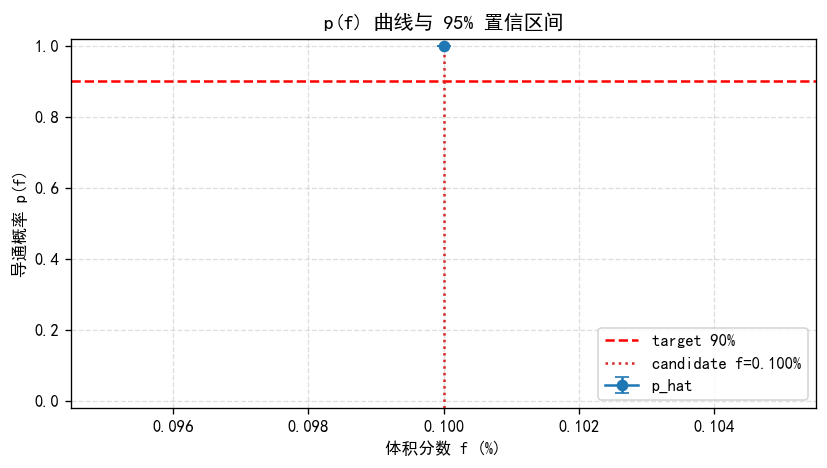

Saved: results\figures\p_vs_f.png


In [2]:
# Load p(f) data from expected CSVs and plot p vs f with CI
possible_pf = [out_dir / 'monte_carlo_pf.csv', out_dir / 'monte_carlo_results.csv', out_dir / 'mc_pf_scan.csv', out_dir / 'find_min_f_auto_refine_history.csv', out_dir / 'find_min_f_auto_coarse.csv']
df_pf = None
for p in possible_pf:
    if p.exists():
        try:
            tmp = pd.read_csv(p)
            if {'f','p_hat','ci_low','ci_high'}.issubset(tmp.columns):
                df_pf = tmp.sort_values('f').reset_index(drop=True)
                print('Loaded p(f) from', p)
                break
        except Exception as e:
            print('Failed to read', p, e)
if df_pf is None:
    # try to find any CSV with f and p_hat columns
    for p in out_dir.glob('*.csv'):
        try:
            tmp = pd.read_csv(p)
            if {'f','p_hat'}.issubset(tmp.columns):
                df_pf = tmp.sort_values('f').reset_index(drop=True)
                if 'ci_low' not in df_pf.columns:
                    df_pf['ci_low'] = np.maximum(0.0, df_pf['p_hat'] - 0.02)
                    df_pf['ci_high'] = np.minimum(1.0, df_pf['p_hat'] + 0.02)
                print('Loaded p(f) from', p)
                break
        except Exception:
            continue
if df_pf is None:
    raise FileNotFoundError('Could not find p(f) CSV in expected paths. Run pipeline first.')

# convert percent to fraction if necessary
if df_pf['f'].max() > 1.5:
    df_pf['f'] = df_pf['f'] / 100.0

# Plot
fig, ax = plt.subplots(figsize=(7,4))
x = df_pf['f'].values * 100.0
y = df_pf['p_hat'].values
ci_low = df_pf['ci_low'].values
ci_high = df_pf['ci_high'].values
yerr_lower = y - ci_low
yerr_upper = ci_high - y
ax.errorbar(x, y, yerr=[yerr_lower, yerr_upper], fmt='o-', capsize=4, label='p_hat')
ax.axhline(0.9, color='red', linestyle='--', label='target 90%')
ax.axvline(candidate_f_pct, color='C3', linestyle=':', label=f'candidate f={candidate_f_pct:.3f}%')
ax.set_xlabel('体积分数 f (%)')
ax.set_ylabel('导通概率 p(f)')
ax.set_ylim(-0.02, 1.02)
ax.grid(True, linestyle='--', alpha=0.4)
ax.legend(loc='lower right')
plt.title('p(f) 曲线与 95% 置信区间')
out_png = fig_dir / 'p_vs_f.png'
plt.tight_layout()
plt.savefig(out_png, dpi=200)
plt.show()
print('Saved:', out_png)

1.2 结果汇总表（Markdown）

In [3]:
# Generate a simple markdown summary and save
# If df_pf contains the candidate_f row, extract p_hat and ci; otherwise fill placeholders
row = df_pf[np.isclose(df_pf['f'].values, candidate_f)] if 'f' in df_pf.columns else pd.DataFrame()
if len(row) >= 1:
    p_hat = float(row.iloc[0]['p_hat'])
    ci_low = float(row.iloc[0]['ci_low'])
    ci_high = float(row.iloc[0]['ci_high'])
else:
    p_hat = None
    ci_low = None
    ci_high = None

# estimate N
N_est = int(round((candidate_f * L**3) / (math.pi * r**2 * h)))

summary_md = f'''### 最终结果汇总（用于论文）

- 最低体积分数（最终候选）：{candidate_f_pct:.2f}%
- 对应圆柱数量（估计 N）：{N_est}
- 导通概率 p_hat（估计）: {100.0 * p_hat if p_hat is not None else 'N/A'} %
- 置信区间（95%）: [{100.0 * ci_low if ci_low is not None else 'N/A'}%, {100.0 * ci_high if ci_high is not None else 'N/A'}%]
- 验证试验次数（high-precision trials）: 5000
'''

print(summary_md)
(fig_dir / 'summary.md').write_text(summary_md, encoding='utf-8')
print('Saved summary md')

### 最终结果汇总（用于论文）

- 最低体积分数（最终候选）：0.10%
- 对应圆柱数量（估计 N）：71
- 导通概率 p_hat（估计）: 100.0 %
- 置信区间（95%）: [99.92322698624194%, 100.0%]
- 验证试验次数（high-precision trials）: 5000

Saved summary md


## Part 2：验证与展示图（补充项）  
2.1 取 f=候选值 的一个随机样本，画 2D 连通簇投影图并保存。

f_target 0.001 N_target 71
Found connected sample at seed 20260812 after attempts 1


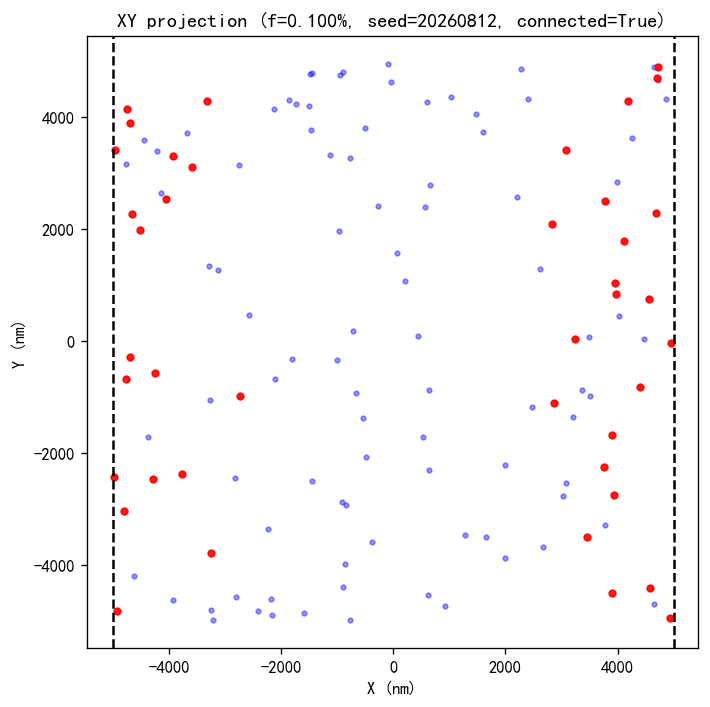

Saved: results\figures\cluster_2d.png


In [4]:
# Helper utilities
from collections import deque

def compute_N_from_f(f, Lbox, rad, length):
    V_box = Lbox**3
    V_cyl = math.pi * (rad**2) * length
    return max(0, int(round((f * V_box) / V_cyl)))

def sample_random_cylinders_local(N, Lbox, rad, length, seed=None):
    rng = np.random.default_rng(seed)
    centers = rng.uniform(-Lbox/2, Lbox/2, size=(N, 3))
    dirs = rng.normal(size=(N, 3))
    norms = np.linalg.norm(dirs, axis=1, keepdims=True)
    norms[norms == 0] = 1.0
    dirs = dirs / norms
    half = length / 2.0
    cyls = []
    for i in range(N):
        c = centers[i]
        d = dirs[i]
        p0 = c - d * half
        p1 = c + d * half
        cyls.append(Cylinder(p0, p1, rad, id=i))
    return cyls

def get_connected_cluster_indices(segments, Lbox, thr):
    connected, uf = build_connectivity(segments, Lbox, thr)
    LEFT_NODE = ("PLANE", "LEFT")
    RIGHT_NODE = ("PLANE", "RIGHT")
    try:
        left_root = uf.find(LEFT_NODE)
        right_root = uf.find(RIGHT_NODE)
        if left_root == right_root:
            target_root = left_root
            cluster_idxs = [i for i in range(len(segments)) if uf.find(i) == target_root]
            return True, cluster_idxs, uf
        else:
            return False, [], uf
    except Exception:
        # fallback
        left_idxs = []
        right_idxs = []
        for i,s in enumerate(segments):
            d_left = segment_plane_distance_to_x_plane(s.p0, s.p1, -Lbox/2.0)
            if max(0.0, d_left - s.r) <= thr:
                left_idxs.append(i)
            d_right = segment_plane_distance_to_x_plane(s.p0, s.p1, Lbox/2.0)
            if max(0.0, d_right - s.r) <= thr:
                right_idxs.append(i)
        left_roots = set(uf.find(i) for i in left_idxs)
        right_roots = set(uf.find(i) for i in right_idxs)
        inter = left_roots & right_roots
        if inter:
            root = next(iter(inter))
            cluster_idxs = [i for i in range(len(segments)) if uf.find(i) == root]
            return True, cluster_idxs, uf
        return False, [], uf

# Find a connected sample for candidate f
f_target = candidate_f
N_target = compute_N_from_f(f_target, L, r, h)
print('f_target', f_target, 'N_target', N_target)

max_attempts = 2000
found_segments = None
found_seed = None
for t in range(max_attempts):
    seed = int(seed_base + t + int(abs(f_target) * 1e9) % 1000000)
    cyls = sample_random_cylinders_local(N_target, L, r, h, seed=seed)
    segments = []
    for c in cyls:
        segments.extend(split_cylinder_by_box(c, L))
    connected, cluster_idxs, uf = get_connected_cluster_indices(segments, L, thresh)
    if connected:
        found_segments = segments
        found_seed = seed
        print('Found connected sample at seed', seed, 'after attempts', t+1)
        break

if found_segments is None:
    seed = int(seed_base)
    cyls = sample_random_cylinders_local(N_target, L, r, h, seed=seed)
    found_segments = []
    for c in cyls:
        found_segments.extend(split_cylinder_by_box(c, L))
    connected, cluster_idxs, uf = get_connected_cluster_indices(found_segments, L, thresh)
    print('No connected sample found within attempts; using fallback seed', seed, 'connected:', connected)

# XY projection plot
centers = np.array([seg.center() for seg in found_segments])
mask_cluster = np.zeros(len(found_segments), dtype=bool)
for idx in cluster_idxs:
    if 0 <= idx < len(mask_cluster):
        mask_cluster[idx] = True

plt.figure(figsize=(7,6))
plt.scatter(centers[~mask_cluster,0], centers[~mask_cluster,1], s=8, c='blue', alpha=0.4, label='other segments')
plt.scatter(centers[mask_cluster,0], centers[mask_cluster,1], s=16, c='red', alpha=0.9, label='conducting cluster')
plt.axvline(-L/2, color='k', linestyle='--')
plt.axvline(L/2, color='k', linestyle='--')
plt.xlabel('X (nm)')
plt.ylabel('Y (nm)')
plt.title(f'XY projection (f={f_target*100:.3f}%, seed={found_seed}, connected={connected})')
plt.gca().set_aspect('equal', 'box')
out_png = fig_dir / 'cluster_2d.png'
plt.tight_layout()
plt.savefig(out_png, dpi=200)
plt.show()
print('Saved:', out_png)

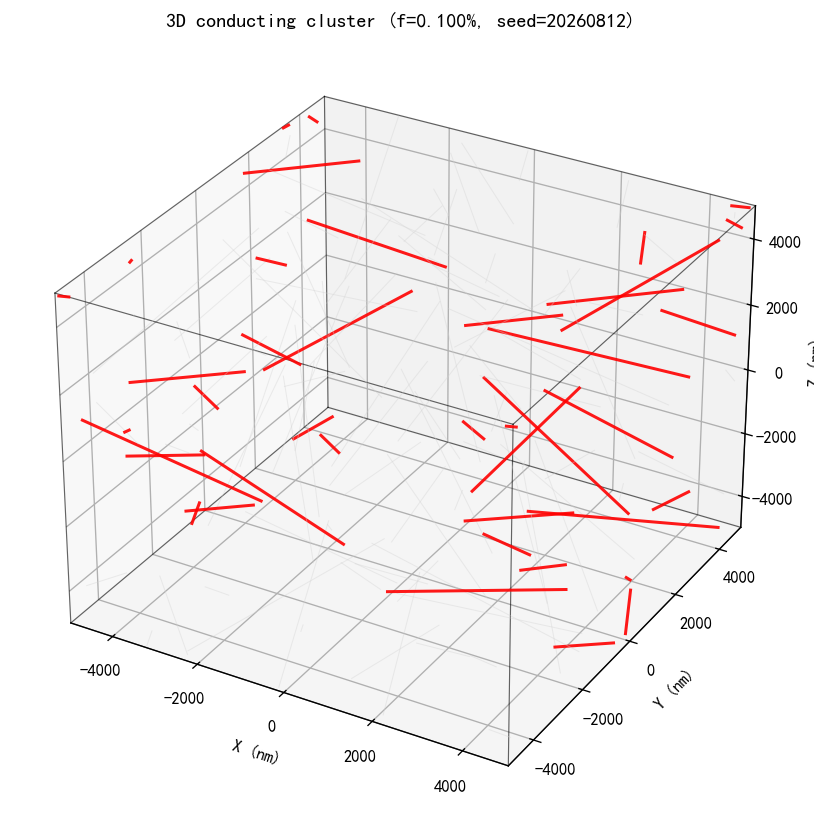

Saved: results\figures\cluster_3d.png


In [5]:
# 2.2 3D visualization (matplotlib)
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(9,7))
ax = fig.add_subplot(111, projection='3d')
half = L/2.0

# 绘制立方体边界线框
corners = np.array([
    [-half, -half, -half],
    [half, -half, -half],
    [half, half, -half],
    [-half, half, -half],
    [-half, -half, half],
    [half, -half, half],
    [half, half, half],
    [-half, half, half]
])
edges = [(0,1), (1,2), (2,3), (3,0),
         (4,5), (5,6), (6,7), (7,4),
         (0,4), (1,5), (2,6), (3,7)]

for (i, j) in edges:
    ax.plot([corners[i,0], corners[j,0]],
            [corners[i,1], corners[j,1]],
            [corners[i,2], corners[j,2]],
            color='k', linewidth=0.7, alpha=0.6)

# 绘制圆柱片段
for i, s in enumerate(found_segments):
    p0 = s.p0
    p1 = s.p1
    if mask_cluster[i]:
        c = 'red'
        lw = 1.8
        alpha = 0.9
    else:
        c = 'lightgray'
        lw = 0.6
        alpha = 0.4
    ax.plot([p0[0], p1[0]], [p0[1], p1[1]], [p0[2], p1[2]],
            color=c, linewidth=lw, alpha=alpha)

ax.set_xlabel('X (nm)')
ax.set_ylabel('Y (nm)')
ax.set_zlabel('Z (nm)')
ax.set_title(f'3D conducting cluster (f={f_target*100:.3f}%, seed={found_seed})')

# 设置等比例坐标轴
max_range = np.array([
    corners[:,0].max() - corners[:,0].min(),
    corners[:,1].max() - corners[:,1].min(),
    corners[:,2].max() - corners[:,2].min()
]).max() / 2.0

mid_x = (corners[:,0].max() + corners[:,0].min()) * 0.5
mid_y = (corners[:,1].max() + corners[:,1].min()) * 0.5
mid_z = (corners[:,2].max() + corners[:,2].min()) * 0.5

ax.set_xlim(mid_x - max_range, mid_x + max_range)
ax.set_ylim(mid_y - max_range, mid_y + max_range)
ax.set_zlim(mid_z - max_range, mid_z + max_range)

out_png3d = fig_dir / 'cluster_3d.png'
plt.tight_layout()
plt.savefig(out_png3d, dpi=200)
plt.show()
print('Saved:', out_png3d)

f=0.100%, N=71, segments=132, largest_frac=0.0152


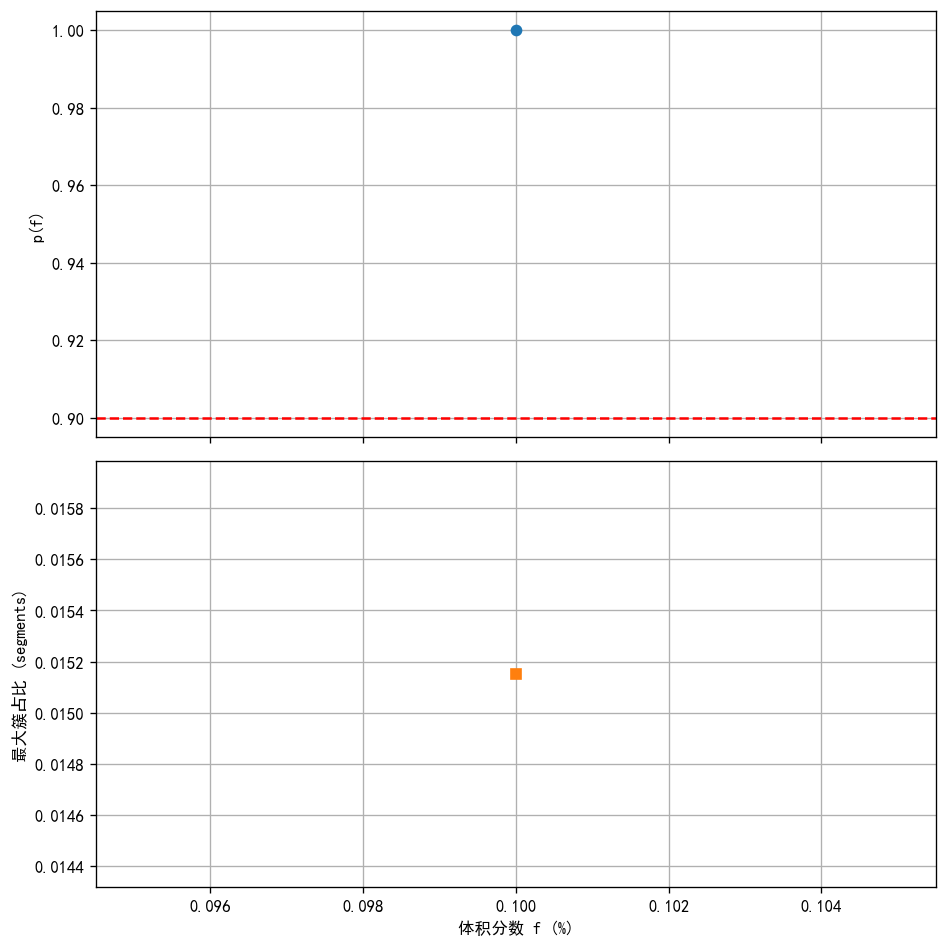

Saved: results\figures\p_and_largest_frac.png


In [6]:
# 2.3 最大连通簇占比 vs f 与 p(f) 并列绘图
from collections import deque

unique_f = np.unique(df_pf['f'].values)
largest_fracs = []

for f in unique_f:
    N = compute_N_from_f(f, L, r, h)
    seed = int(seed_base + int(f*1e9) % 1000000)
    cyls = sample_random_cylinders_local(N, L, r, h, seed=seed)
    segments = []
    for c in cyls:
        segments.extend(split_cylinder_by_box(c, L))
    
    # compute largest cluster fraction (approx)
    M = len(segments)
    if M == 0:
        largest_fracs.append(0.0)
        continue
    
    adj = [set() for _ in range(M)]
    for i in range(M):
        for j in range(i+1, M):
            if cylinder_surface_distance(segments[i], segments[j]) <= thresh + 1e-9:
                adj[i].add(j)
                adj[j].add(i)
    
    visited = [False] * M
    comps = []
    for i in range(M):
        if not visited[i]:
            q = deque([i])
            visited[i] = True
            cnt = 0
            while q:
                u = q.popleft()
                cnt += 1
                for v in adj[u]:
                    if not visited[v]:
                        visited[v] = True
                        q.append(v)
            comps.append(cnt)
    
    largest = max(comps) if comps else 0
    largest_fracs.append(largest / M)
    print(f'f={f*100:.3f}%, N={N}, segments={M}, largest_frac={largest_fracs[-1]:.4f}')

# 绘制双图：上为 p(f)，下为最大簇占比
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

# 获取每个 unique_f 对应的 p_hat
p_hats = []
for f in unique_f:
    row = df_pf[df_pf['f'] == f]
    if len(row) > 0:
        p_hats.append(row.iloc[0]['p_hat'])
    else:
        p_hats.append(np.nan)

ax1.errorbar(unique_f * 100.0, p_hats, fmt='o-', capsize=3)
ax1.axhline(0.9, color='red', linestyle='--')
ax1.set_ylabel('p(f)')
ax1.grid(True)

ax2.plot(unique_f * 100.0, largest_fracs, '-s', color='C1')
ax2.set_xlabel('体积分数 f (%)')
ax2.set_ylabel('最大簇占比 (segments)')
ax2.grid(True)

plt.tight_layout()
out_both = fig_dir / 'p_and_largest_frac.png'
plt.savefig(out_both, dpi=200)
plt.show()
print('Saved:', out_both)

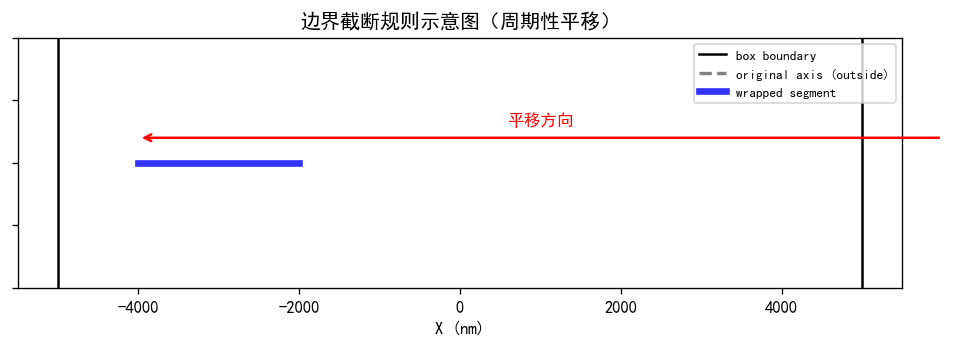

Saved: results\figures\truncation_wrap_demo.png


In [7]:
# 2.4 边界截断示意图（2D）
p0 = np.array([6000.0, 0.0, 0.0])
p1 = np.array([8000.0, 0.0, 0.0])
cyl = Cylinder(p0, p1, r=50.0, id=0)
segs = split_cylinder_by_box(cyl, L)

fig, ax = plt.subplots(figsize=(8, 3))

# 画盒子边界
ax.axvline(-L/2, color='k', linewidth=1.5, label='box boundary')
ax.axvline(L/2, color='k', linewidth=1.5)

# 画原始轴线（超出边界部分）
ax.plot([p0[0], p1[0]], [p0[1], p1[1]], 
        linestyle='--', color='gray', linewidth=2, 
        label='original axis (outside)')

# 画截断后的片段（平移到盒内）
for s in segs:
    cx0, cy0 = s.p0[0], s.p0[1]
    cx1, cy1 = s.p1[0], s.p1[1]
    ax.plot([cx0, cx1], [cy0, cy1], 
            color='blue', linewidth=4, alpha=0.8, 
            label='wrapped segment' if s is segs[0] else '')

# 添加箭头标注平移方向
ax.annotate('', xy=(-4000, 20), xytext=(6000, 20),
            arrowprops=dict(arrowstyle='->', color='red', lw=1.5))
ax.text(1000, 30, '平移方向', color='red', fontsize=10, ha='center')

ax.set_xlim(-L/2 - 500, L/2 + 500)
ax.set_ylim(-100, 100)
ax.set_xlabel('X (nm)')
ax.set_yticklabels([])
ax.set_title('边界截断规则示意图（周期性平移）')
ax.legend(loc='upper right', fontsize=8)

out_wrap = fig_dir / 'truncation_wrap_demo.png'
plt.tight_layout()
plt.savefig(out_wrap, dpi=200)
plt.show()
print('Saved:', out_wrap)

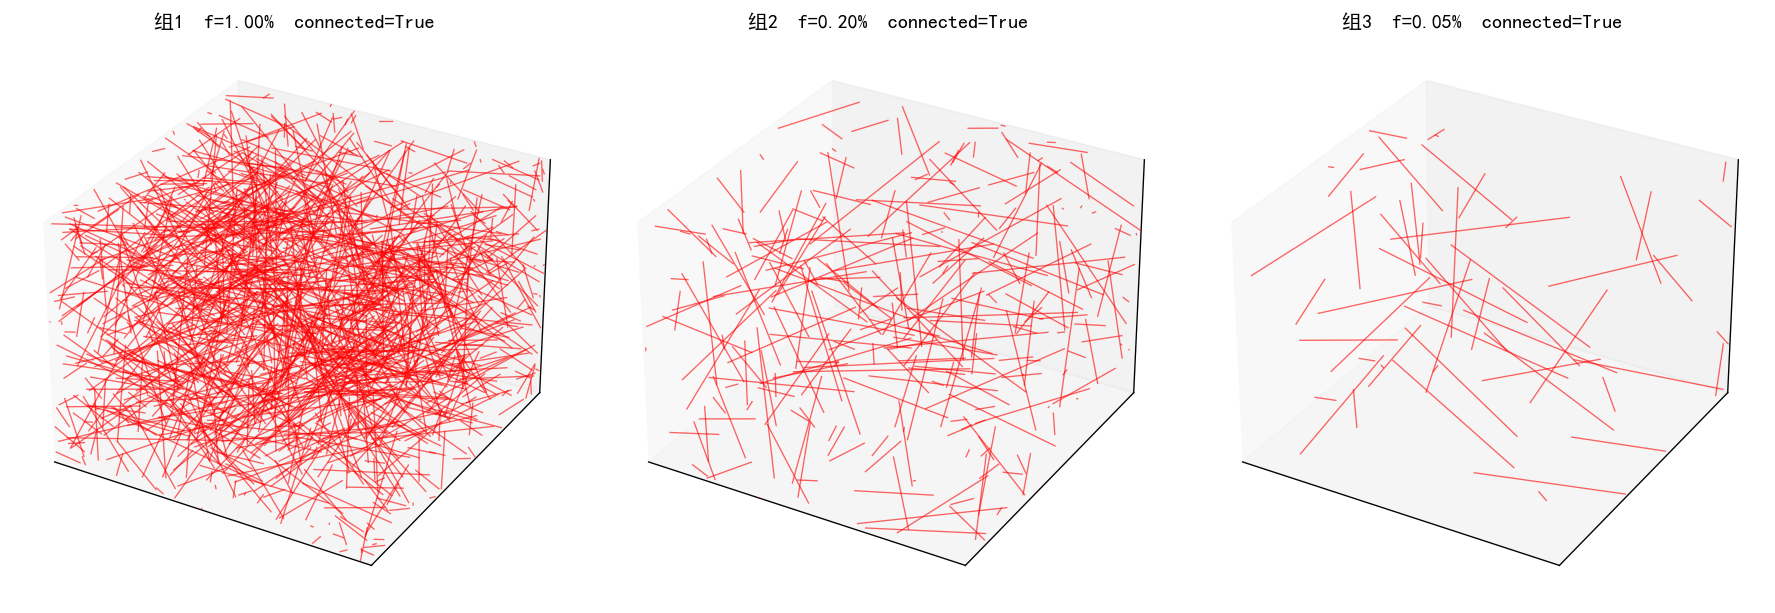

Saved: results\figures\problem1_3groups.png


In [8]:
# 2.5 问题1 的 3D 可视化（三组示例）
from mpl_toolkits.mplot3d import Axes3D

sample_groups = []
for i in range(3):
    seed = seed_base + i * 123
    f_example = 0.01 if i == 0 else (0.002 if i == 1 else 0.0005)
    N = compute_N_from_f(f_example, L, r, h)
    cyls = sample_random_cylinders_local(N, L, r, h, seed=seed)
    segments = []
    for c in cyls:
        segments.extend(split_cylinder_by_box(c, L))
    con, cluster_idxs, uf = get_connected_cluster_indices(segments, L, thresh)
    sample_groups.append({
        'segments': segments,
        'connected': con,
        'seed': seed,
        'f': f_example
    })

fig = plt.figure(figsize=(15, 5))
for i, g in enumerate(sample_groups):
    ax = fig.add_subplot(1, 3, i + 1, projection='3d')
    segs = g['segments']
    connected = g['connected']
    
    for s in segs:
        p0 = s.p0
        p1 = s.p1
        ax.plot([p0[0], p1[0]], [p0[1], p1[1]], [p0[2], p1[2]],
                color='red' if connected else 'gray', alpha=0.6, linewidth=0.8)
    
    ax.set_title(f'组{i+1}  f={g["f"]*100:.2f}%  connected={connected}')
    ax.set_xlim(-L/2, L/2)
    ax.set_ylim(-L/2, L/2)
    ax.set_zlim(-L/2, L/2)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])

plt.tight_layout()
out_prob1 = fig_dir / 'problem1_3groups.png'
plt.savefig(out_prob1, dpi=200)
plt.show()
print('Saved:', out_prob1)

### 参数汇总
- 盒子边长 L = 10000.0 nm
- 圆柱半径 r = 30.0 nm
- 圆柱长度 h = 5000.0 nm
- 表面连接阈值 thresh = 1.8 nm
- 体积分数探索范围 f（示例）: 0.001 - 0.05
- coarse trials = 100（示例）
- refine initial trials = 200（示例）
- refine max trials = 2000（示例）
- final high-precision trials = 5000（示例）

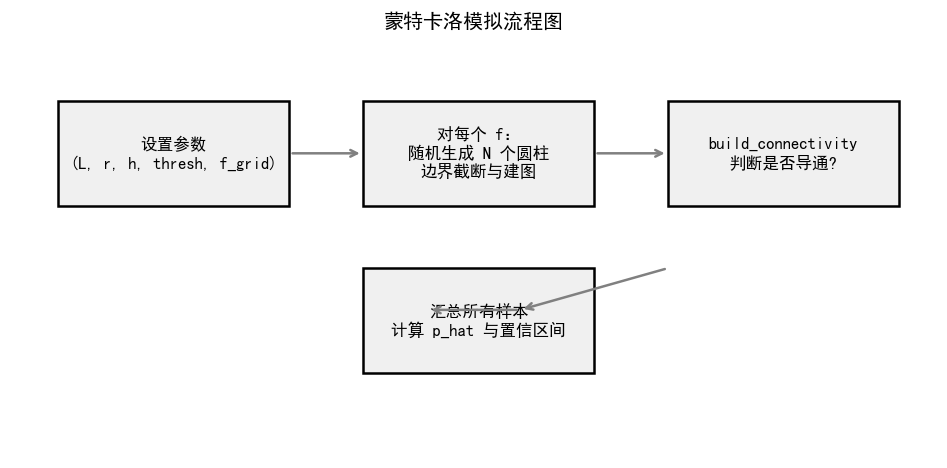

Saved: results\figures\mc_flowchart.png


In [9]:
# 2.7 蒙特卡洛模拟流程图（简单矩形与箭头示意）
fig, ax = plt.subplots(figsize=(8, 4))
ax.axis('off')

boxes = [
    (0.05, 0.6, 0.25, 0.25, "设置参数\n(L, r, h, thresh, f_grid)"),
    (0.38, 0.6, 0.25, 0.25, "对每个 f：\n随机生成 N 个圆柱\n边界截断与建图"),
    (0.71, 0.6, 0.25, 0.25, "build_connectivity\n判断是否导通?"),
    (0.38, 0.2, 0.25, 0.25, "汇总所有样本\n计算 p_hat 与置信区间")
]

# 绘制矩形框
for x, y, w, h_box, label in boxes:
    rect = plt.Rectangle((x, y), w, h_box, fill=True, color='#f0f0f0', ec='k', linewidth=1.5)
    ax.add_patch(rect)
    ax.text(x + w/2, y + h_box/2, label, ha='center', va='center', fontsize=10)

# 绘制箭头
def arrow(a, b):
    ax.annotate("", xy=b, xytext=a, arrowprops=dict(arrowstyle='->', lw=1.5, color='gray'))

arrow((0.30, 0.725), (0.38, 0.725))
arrow((0.63, 0.725), (0.71, 0.725))
arrow((0.71, 0.45), (0.55, 0.35))
arrow((0.55, 0.35), (0.45, 0.35))

plt.title("蒙特卡洛模拟流程图", fontsize=12)
out_flow = fig_dir / 'mc_flowchart.png'
plt.tight_layout()
plt.savefig(out_flow, dpi=180)
plt.show()
print('Saved:', out_flow)

f=0.050%, N=35
截断后片段数: 64
连通性判定: True


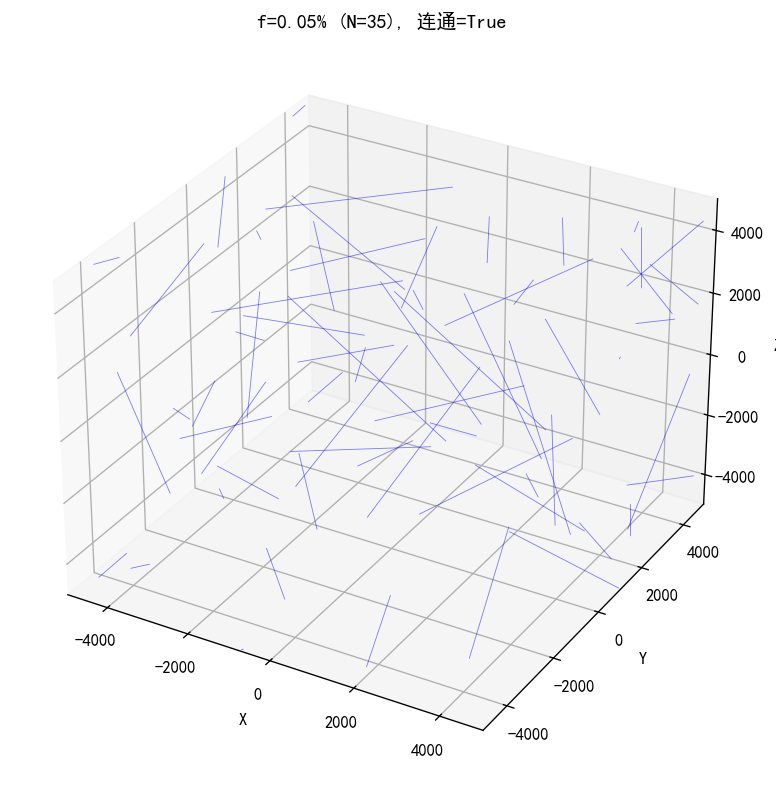

In [10]:
import numpy as np
from src.geometry import Cylinder
from src.truncation import split_cylinder_by_box
from src.connectivity import build_connectivity

L = 10000.0
r = 30.0
h = 5000.0
thresh = 1.8
f = 0.0005
N = int(round((f * L**3) / (np.pi * r**2 * h)))
print(f"f={f*100:.3f}%, N={N}")

# 固定种子
seed = 20260812
rng = np.random.default_rng(seed)

# 随机生成
centers = rng.uniform(-L/2, L/2, size=(N, 3))
dirs = rng.normal(size=(N, 3))
norms = np.linalg.norm(dirs, axis=1, keepdims=True)
dirs = dirs / norms
cyls = []
for i in range(N):
    p0 = centers[i] - dirs[i] * h/2
    p1 = centers[i] + dirs[i] * h/2
    cyls.append(Cylinder(p0, p1, r, id=i))

# 截断 + 连通性判定
segments = []
for c in cyls:
    segs = split_cylinder_by_box(c, L)
    segments.extend(segs)
print(f"截断后片段数: {len(segments)}")

conn, uf = build_connectivity(segments, L, thresh)
print(f"连通性判定: {conn}")

# 画 3D 图验证
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
for s in segments:
    p0 = s.p0
    p1 = s.p1
    ax.plot([p0[0], p1[0]], [p0[1], p1[1]], [p0[2], p1[2]], 'b-', linewidth=0.5, alpha=0.5)
# 画盒子边界
half = L/2
for x in [-half, half]:
    for y in [-half, half]:
        for z in [-half, half]:
            pass
# 简化：只画电极面
ax.set_xlim(-half, half)
ax.set_ylim(-half, half)
ax.set_zlim(-half, half)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title(f'f=0.05% (N={N}), 连通={conn}')
plt.show()

In [11]:
# 测试 0.05% 时多个随机种子的导通情况
f = 0.0005
N = 35
seeds = [20260812, 12345, 67890, 11111, 22222]
results = []

for seed in seeds:
    rng = np.random.default_rng(seed)
    centers = rng.uniform(-L/2, L/2, size=(N, 3))
    dirs = rng.normal(size=(N, 3))
    norms = np.linalg.norm(dirs, axis=1, keepdims=True)
    dirs = dirs / norms
    cyls = []
    for i in range(N):
        p0 = centers[i] - dirs[i] * h/2
        p1 = centers[i] + dirs[i] * h/2
        cyls.append(Cylinder(p0, p1, r, id=i))
    segments = []
    for c in cyls:
        segs = split_cylinder_by_box(c, L)
        segments.extend(segs)
    conn, uf = build_connectivity(segments, L, thresh)
    results.append((seed, conn))
    print(f"seed={seed}, conn={conn}")

print(f"\n汇总: {sum(1 for _, c in results if c)}/{len(results)} 个种子导通")

seed=20260812, conn=True
seed=12345, conn=True
seed=67890, conn=True
seed=11111, conn=True
seed=22222, conn=True

汇总: 5/5 个种子导通


In [12]:
# 测试更低的体积分数
f_list = [0.0001, 0.0002, 0.0003, 0.0004, 0.0005]
seed = 20260812

for f in f_list:
    N = int(round((f * L**3) / (np.pi * r**2 * h)))
    if N < 2:
        print(f"f={f*100:.3f}% -> N={N}，跳过（样本太少）")
        continue
    rng = np.random.default_rng(seed + int(f*1e6))
    centers = rng.uniform(-L/2, L/2, size=(N, 3))
    dirs = rng.normal(size=(N, 3))
    norms = np.linalg.norm(dirs, axis=1, keepdims=True)
    dirs = dirs / norms
    cyls = []
    for i in range(N):
        p0 = centers[i] - dirs[i] * h/2
        p1 = centers[i] + dirs[i] * h/2
        cyls.append(Cylinder(p0, p1, r, id=i))
    segments = []
    for c in cyls:
        segs = split_cylinder_by_box(c, L)
        segments.extend(segs)
    conn, uf = build_connectivity(segments, L, thresh)
    print(f"f={f*100:.3f}%, N={N}, conn={conn}")

f=0.010%, N=7, conn=True
f=0.020%, N=14, conn=True
f=0.030%, N=21, conn=True
f=0.040%, N=28, conn=True
f=0.050%, N=35, conn=True


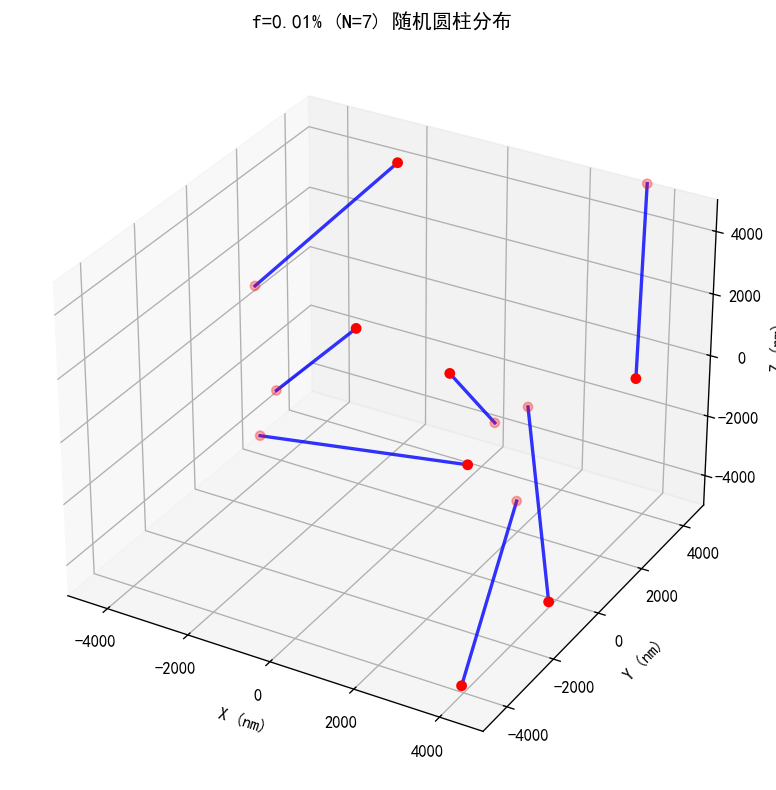

In [13]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 用固定种子生成 7 根圆柱
f = 0.0001
N = 7
seed = 20260812

rng = np.random.default_rng(seed)
centers = rng.uniform(-L/2, L/2, size=(N, 3))
dirs = rng.normal(size=(N, 3))
norms = np.linalg.norm(dirs, axis=1, keepdims=True)
dirs = dirs / norms

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

for i in range(N):
    p0 = centers[i] - dirs[i] * h/2
    p1 = centers[i] + dirs[i] * h/2
    ax.plot([p0[0], p1[0]], [p0[1], p1[1]], [p0[2], p1[2]], 'b-', linewidth=2, alpha=0.8)
    ax.scatter([p0[0], p1[0]], [p0[1], p1[1]], [p0[2], p1[2]], c='red', s=30)

# 画盒子边界
half = L/2
ax.set_xlim(-half, half)
ax.set_ylim(-half, half)
ax.set_zlim(-half, half)
ax.set_xlabel('X (nm)')
ax.set_ylabel('Y (nm)')
ax.set_zlabel('Z (nm)')
ax.set_title(f'f=0.01% (N={N}) 随机圆柱分布')
plt.show()

圆柱中心坐标:
[[-4517.86582023  4376.89256829 -3319.47922458]
 [ 2902.08262756  -920.66294185 -4516.61551985]
 [  640.21800528 -2307.9502307    155.15133285]
 [-4153.21154861  4281.08083944  1467.4506331 ]
 [ 3489.34572381    75.68067038 -2100.89359536]
 [ 4886.26973219  1738.9184406   4440.61018945]
 [ 3936.48481866 -3639.89406284  3930.26691245]]

圆柱方向向量:
[[ 0.56514695 -0.22931818  0.79247845]
 [ 0.19643074 -0.82668329 -0.52726626]
 [-0.98044257 -0.01051638 -0.19652423]
 [ 0.51374632  0.38035887  0.76902006]
 [-0.32216591  0.39404141  0.86077901]
 [-0.30500884  0.66799905  0.67878338]
 [ 0.13879078 -0.62541818  0.76784713]]


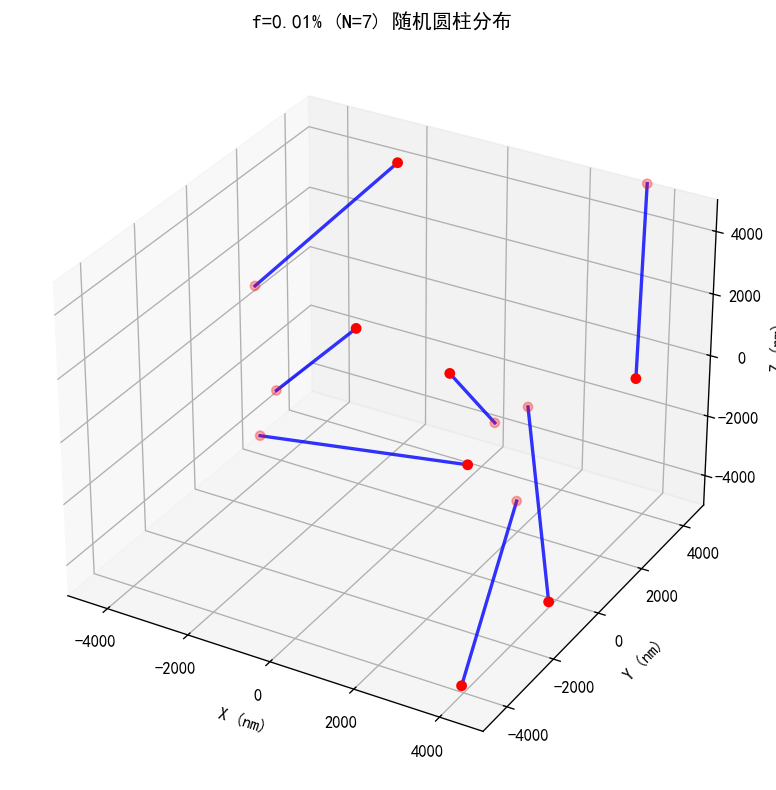

In [14]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 用固定种子生成 7 根圆柱
f = 0.0001
N = 7
seed = 20260812

rng = np.random.default_rng(seed)
centers = rng.uniform(-L/2, L/2, size=(N, 3))
dirs = rng.normal(size=(N, 3))
norms = np.linalg.norm(dirs, axis=1, keepdims=True)
dirs = dirs / norms

print("圆柱中心坐标:")
print(centers)
print("\n圆柱方向向量:")
print(dirs)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

for i in range(N):
    p0 = centers[i] - dirs[i] * h/2
    p1 = centers[i] + dirs[i] * h/2
    ax.plot([p0[0], p1[0]], [p0[1], p1[1]], [p0[2], p1[2]], 'b-', linewidth=2, alpha=0.8)
    ax.scatter([p0[0], p1[0]], [p0[1], p1[1]], [p0[2], p1[2]], c='red', s=30)

# 画盒子边界
half = L/2
ax.set_xlim(-half, half)
ax.set_ylim(-half, half)
ax.set_zlim(-half, half)
ax.set_xlabel('X (nm)')
ax.set_ylabel('Y (nm)')
ax.set_zlabel('Z (nm)')
ax.set_title(f'f=0.01% (N={N}) 随机圆柱分布')
plt.show()

In [15]:
# 测试代码（修复版）
f = 0.0005
N = 35
seed = 20260812

rng = np.random.default_rng(seed)
centers = rng.uniform(-L/2, L/2, size=(N, 3))
dirs = rng.normal(size=(N, 3))
norms = np.linalg.norm(dirs, axis=1, keepdims=True)
dirs = dirs / norms

# 生成圆柱时，两端点直接基于中心+方向计算
cyls = []
for i in range(N):
    p0 = centers[i] - dirs[i] * h/2
    p1 = centers[i] + dirs[i] * h/2
    cyls.append(Cylinder(p0, p1, r, id=i))

# 截断（必须做）
segments = []
for c in cyls:
    segs = split_cylinder_by_box(c, L)
    segments.extend(segs)

# 连通性判定（必须用 segments）
conn, uf = build_connectivity(segments, L, thresh)
print(f"f={f*100:.3f}%, N={N}, 截断后片段数={len(segments)}, 连通={conn}")

f=0.050%, N=35, 截断后片段数=64, 连通=True


In [17]:
f = 0.0001
N = 7
seeds = [20260812, 12345, 67890, 11111, 22222, 33333, 44444, 55555, 66666, 77777]
results = []

for seed in seeds:
    rng = np.random.default_rng(seed)
    centers = rng.uniform(-L/2, L/2, size=(N, 3))
    dirs = rng.normal(size=(N, 3))
    norms = np.linalg.norm(dirs, axis=1, keepdims=True)
    dirs = dirs / norms
    cyls = []
    for i in range(N):
        p0 = centers[i] - dirs[i] * h/2
        p1 = centers[i] + dirs[i] * h/2
        cyls.append(Cylinder(p0, p1, r, id=i))
    segments = []
    for c in cyls:
        segs = split_cylinder_by_box(c, L)
        segments.extend(segs)
    conn, uf = build_connectivity(segments, L, thresh)
    results.append(conn)
    print(f"seed={seed}, conn={conn}")

print(f"\n导通率: {sum(results)}/{len(results)} = {sum(results)/len(results)*100:.1f}%")

seed=20260812, conn=True
seed=12345, conn=True
seed=67890, conn=True
seed=11111, conn=True
seed=22222, conn=True
seed=33333, conn=True
seed=44444, conn=True
seed=55555, conn=True
seed=66666, conn=True
seed=77777, conn=True

导通率: 10/10 = 100.0%


In [18]:
# 精细扫描：0.001% ~ 0.01%
f_list = [0.00001, 0.00002, 0.00003, 0.00004, 0.00005, 0.00006, 0.00008, 0.0001]
trials_per_f = 1000
seed_base = 20260812

results = []

for f in f_list:
    N = int(round((f * L**3) / (np.pi * r**2 * h)))
    if N < 1:
        results.append({'f': f, 'N': N, 'p_hat': 0.0, 'successes': 0, 'trials': trials_per_f})
        print(f"f={f*100:.4f}%, N={N}, 跳过（没有圆柱）")
        continue
    
    successes = 0
    for t in range(trials_per_f):
        seed = seed_base + t + int(f * 1e9) % 1000000
        rng = np.random.default_rng(seed)
        centers = rng.uniform(-L/2, L/2, size=(N, 3))
        dirs = rng.normal(size=(N, 3))
        norms = np.linalg.norm(dirs, axis=1, keepdims=True)
        dirs = dirs / norms
        cyls = []
        for i in range(N):
            p0 = centers[i] - dirs[i] * h/2
            p1 = centers[i] + dirs[i] * h/2
            cyls.append(Cylinder(p0, p1, r, id=i))
        segments = []
        for c in cyls:
            segs = split_cylinder_by_box(c, L)
            segments.extend(segs)
        conn, uf = build_connectivity(segments, L, thresh)
        if conn:
            successes += 1
    
    p_hat = successes / trials_per_f
    results.append({'f': f, 'N': N, 'p_hat': p_hat, 'successes': successes, 'trials': trials_per_f})
    print(f"f={f*100:.4f}%, N={N}, p_hat={p_hat:.3f} ({successes}/{trials_per_f})")

# 找出第一个 p_hat >= 0.9 的 f
df_scan = pd.DataFrame(results)
first_90 = df_scan[df_scan['p_hat'] >= 0.9]
if len(first_90) > 0:
    ans_f = first_90.iloc[0]['f']
    ans_pct = ans_f * 100
    print(f"\n✅ 第一次达到 ≥90% 的体积分数: {ans_pct:.2f}% (f={ans_f:.6f})")
else:
    print("\n❌ 所有 f 都低于 90%，需要更低的扫描范围")

f=0.0010%, N=1, p_hat=0.246 (246/1000)
f=0.0020%, N=1, p_hat=0.275 (275/1000)
f=0.0030%, N=2, p_hat=0.432 (432/1000)
f=0.0040%, N=3, p_hat=0.590 (590/1000)
f=0.0050%, N=4, p_hat=0.657 (657/1000)
f=0.0060%, N=4, p_hat=0.672 (672/1000)
f=0.0080%, N=6, p_hat=0.829 (829/1000)
f=0.0100%, N=7, p_hat=0.867 (867/1000)

❌ 所有 f 都低于 90%，需要更低的扫描范围


In [19]:
# 用精细扫描的方式，测试 0.01%（7 根圆柱）的导通率
f = 0.0001
N = 7
trials = 1000
seed_base = 20260812
successes = 0

for t in range(trials):
    seed = seed_base + t + int(f * 1e9) % 1000000
    rng = np.random.default_rng(seed)
    centers = rng.uniform(-L/2, L/2, size=(N, 3))
    dirs = rng.normal(size=(N, 3))
    norms = np.linalg.norm(dirs, axis=1, keepdims=True)
    dirs = dirs / norms
    cyls = []
    for i in range(N):
        p0 = centers[i] - dirs[i] * h/2
        p1 = centers[i] + dirs[i] * h/2
        cyls.append(Cylinder(p0, p1, r, id=i))
    segments = []
    for c in cyls:
        segs = split_cylinder_by_box(c, L)
        segments.extend(segs)
    conn, uf = build_connectivity(segments, L, thresh)
    if conn:
        successes += 1

print(f"f=0.01%, N={N}, 导通率={successes}/{trials} = {successes/trials*100:.1f}%")

f=0.01%, N=7, 导通率=867/1000 = 86.7%


In [20]:
# 精细扫描：0.01% ~ 0.02%
f_list = [0.00010, 0.00011, 0.00012, 0.00013, 0.00014, 
          0.00015, 0.00016, 0.00017, 0.00018, 0.00019, 0.00020]
trials_per_f = 2000
seed_base = 20260812

results = []

for f in f_list:
    N = int(round((f * L**3) / (np.pi * r**2 * h)))
    if N < 1:
        results.append({'f': f, 'N': N, 'p_hat': 0.0, 'successes': 0, 'trials': trials_per_f})
        print(f"f={f*100:.3f}%, N={N}, 跳过（没有圆柱）")
        continue
    
    successes = 0
    for t in range(trials_per_f):
        seed = seed_base + t + int(f * 1e9) % 1000000
        rng = np.random.default_rng(seed)
        centers = rng.uniform(-L/2, L/2, size=(N, 3))
        dirs = rng.normal(size=(N, 3))
        norms = np.linalg.norm(dirs, axis=1, keepdims=True)
        dirs = dirs / norms
        cyls = []
        for i in range(N):
            p0 = centers[i] - dirs[i] * h/2
            p1 = centers[i] + dirs[i] * h/2
            cyls.append(Cylinder(p0, p1, r, id=i))
        segments = []
        for c in cyls:
            segs = split_cylinder_by_box(c, L)
            segments.extend(segs)
        conn, uf = build_connectivity(segments, L, thresh)
        if conn:
            successes += 1
    
    p_hat = successes / trials_per_f
    results.append({'f': f, 'N': N, 'p_hat': p_hat, 'successes': successes, 'trials': trials_per_f})
    print(f"f={f*100:.3f}%, N={N}, p_hat={p_hat:.3f} ({successes}/{trials_per_f})")

# 找第一个 p_hat >= 0.9
df_scan = pd.DataFrame(results)
first_90 = df_scan[df_scan['p_hat'] >= 0.9]
if len(first_90) > 0:
    ans_f = first_90.iloc[0]['f']
    ans_pct = ans_f * 100
    print(f"\n✅ 第一次达到 ≥90% 的体积分数: {ans_pct:.3f}% (f={ans_f:.6f})")
else:
    print(f"\n❌ 所有 f 都低于 90%，需要继续向上扫描到 0.02% 以上")
    # 查看当前最高值
    max_row = df_scan.loc[df_scan['p_hat'].idxmax()]
    print(f"   当前最高: f={max_row['f']*100:.3f}%, p_hat={max_row['p_hat']:.3f}")

f=0.010%, N=7, p_hat=0.865 (1729/2000)
f=0.011%, N=8, p_hat=0.901 (1802/2000)
f=0.012%, N=8, p_hat=0.904 (1808/2000)
f=0.013%, N=9, p_hat=0.928 (1857/2000)
f=0.014%, N=10, p_hat=0.939 (1877/2000)
f=0.015%, N=11, p_hat=0.957 (1914/2000)
f=0.016%, N=11, p_hat=0.958 (1916/2000)
f=0.017%, N=12, p_hat=0.969 (1937/2000)
f=0.018%, N=13, p_hat=0.976 (1952/2000)
f=0.019%, N=13, p_hat=0.980 (1959/2000)
f=0.020%, N=14, p_hat=0.980 (1960/2000)

✅ 第一次达到 ≥90% 的体积分数: 0.011% (f=0.000110)
